# 

## Import CSV


In [39]:
import pandas as pd
import matplotlib.pyplot as plt #use for plotting
from sklearn.model_selection import train_test_split
import numpy as np

data = pd.read_csv("./dataset.csv")

#print some data infomation
print("Datashape: ",data.shape) #getting the number of rows
print("Columns name: ",data.columns) #getting the columns names

Datashape:  (1956, 6)
Columns name:  Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'VIDEO_NAME', 'CLASS'], dtype='object')


In [40]:
# print first 5 rows
print("First 5 rows: ",data.head(5))

First 5 rows:                                      COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

                       VIDEO_NAME  CLASS  
0  PSY - GANGNAM STYLE(?????) M/V      1  
1  PSY - GANGNAM STYLE(????

Class count:  CLASS
1    1005
0     951
Name: count, dtype: int64


(np.float64(-1.09999995552707),
 np.float64(1.0999997201887033),
 np.float64(-1.0999998295294333),
 np.float64(1.099999991882354))

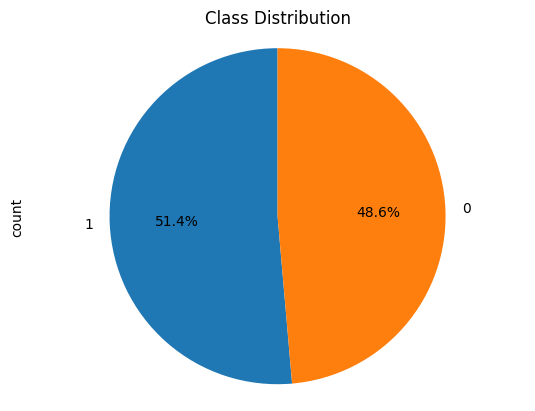

In [41]:
#count class
print("Class count: ",data['CLASS'].value_counts())
#plot to pie chart
data['CLASS'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.

Videos name count:  VIDEO_NAME
Eminem - Love The Way You Lie ft. Rihanna                 448
LMFAO - Party Rock Anthem ft. Lauren Bennett, GoonRock    438
Shakira - Waka Waka                                       370
PSY - GANGNAM STYLE(?????) M/V                            350
Katy Perry - Roar                                         350
Name: count, dtype: int64


<Axes: xlabel='VIDEO_NAME'>

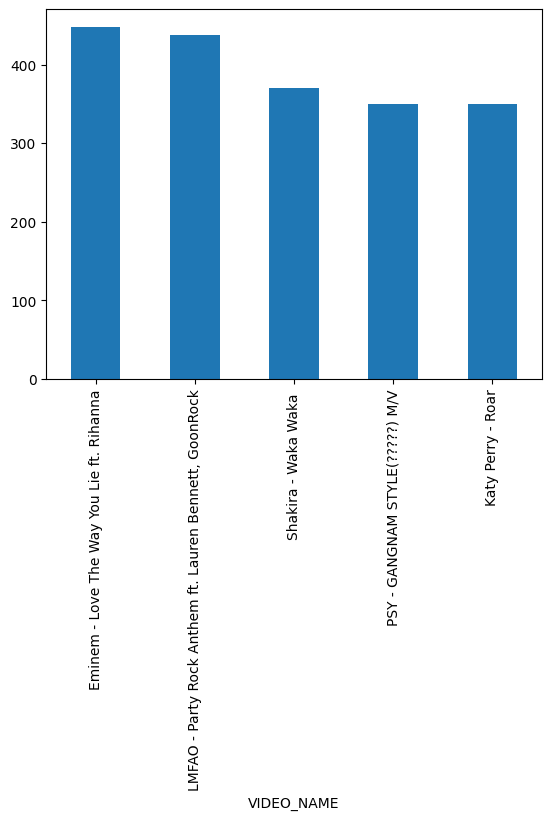

In [42]:
#count videos name 
print("Videos name count: ",data['VIDEO_NAME'].value_counts())
#make to graph
data['VIDEO_NAME'].value_counts().plot(kind='bar')


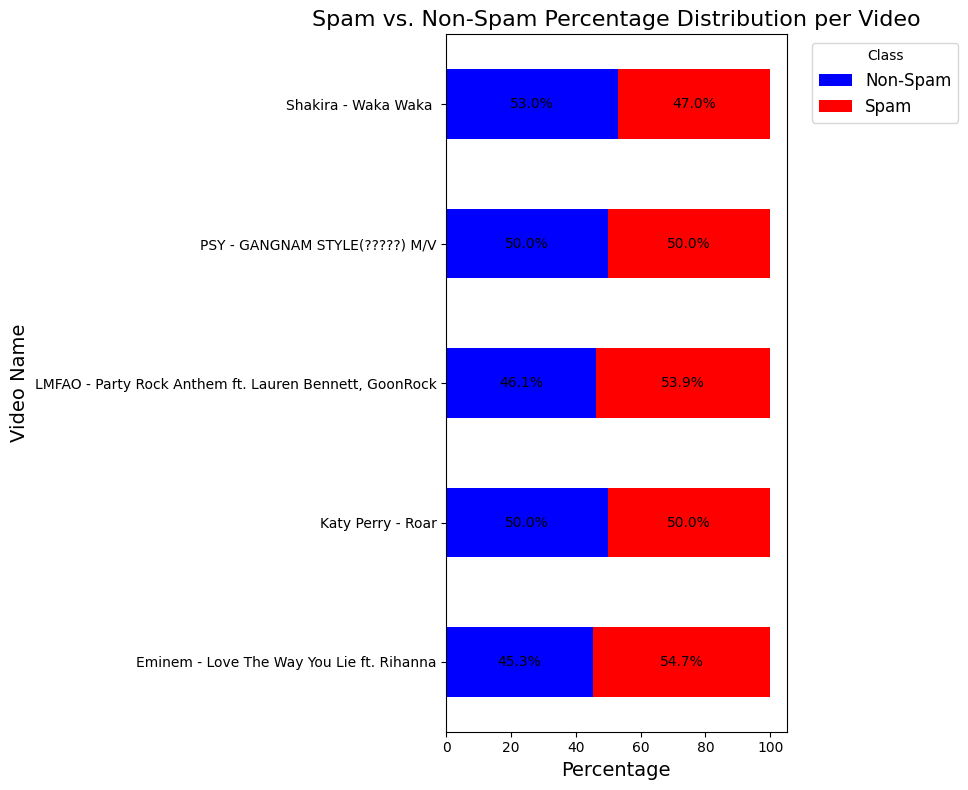

In [43]:
video_class_counts = data.groupby(['VIDEO_NAME', 'CLASS']).size().unstack(fill_value=0)

# Calculate the percentage for each class (spam/non-spam)
video_class_percent = video_class_counts.div(video_class_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar plot for spam vs. non-spam distribution per video (horizontal)
plt.figure(figsize=(10, 8))
ax = video_class_percent.plot(kind='barh', stacked=True, color=['blue', 'red'], ax=plt.gca())

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, color='black')

# Move the legend outside of the plot
ax.legend(title='Class', labels=['Non-Spam', 'Spam'], fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Spam vs. Non-Spam Percentage Distribution per Video', fontsize=16)
plt.ylabel('Video Name', fontsize=14)
plt.xlabel('Percentage', fontsize=14)
plt.tight_layout()

# Show the plot
plt.show()

# Making Navie Bayers


## create Training dataset 

In [44]:
train_data, test_data = train_test_split(data, test_size=0.1, random_state=42)

train_data

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
1532,LneaDw26bFv9y-1cf9oawnpCocMFtK6HXTRuoffJR2k,Complete Pranks,NaN,Subscribe and like my video please,Eminem - Love The Way You Lie ft. Rihanna,1
1160,z12fcjxowubrsnwx104cftlgcpfzw5uwbug0k,Izana,2015-05-28T20:46:16.348000,"I love this song, can&#39;t believe it was 5 y...",Eminem - Love The Way You Lie ft. Rihanna,0
1906,_2viQ_Qnc6978LweIjWZsjP3qK1bgFSYyumKWxPsq_I,Titan,2013-08-08T21:16:25.626000,"Subscribe me, I will? subscribe you back!!!",Shakira - Waka Waka,1
572,z13nujhysyf3ftvgt04ccrd4szrxcvzbvt00k,MeSoHornyMeLuvULongTime,2014-10-18T04:58:21,This video is so racist!!! There are only anim...,Katy Perry - Roar,0
692,z13uuxnivmfpvplmi23vvrdhsku1vpnfy,KillerDan,2015-06-05T17:59:36,"Almost 1 Bil. What? Wow, GS sucks, in my opini...",Katy Perry - Roar,0
...,...,...,...,...,...,...
1130,z121szzyozr4vpqqc04cdn5g4zjhutdosdw,ItsJoey Dash,2014-07-22T10:04:05.755000,EVERYONE PLEASE SUBSCRIBE TO MY CHANNEL OR CAN...,"LMFAO - Party Rock Anthem ft. Lauren Bennett, ...",1
1294,LneaDw26bFvtmJorLbUQjuqmpL7TdjOKPGJT_DGUUJ4,louis canellony,NaN,watch youtube video &quot;EMINEM -YTMA artist ...,Eminem - Love The Way You Lie ft. Rihanna,1
860,z13cfr5o3mnyez4ju04ce3whmvflg1fifl00k,vieshva .d.exodous,2015-05-18T08:38:34.236000,Awesome﻿,"LMFAO - Party Rock Anthem ft. Lauren Bennett, ...",0
1459,z12rhdkrvvy3hd42c23whdeavkjdxnimg,viviane trinh,2015-05-21T22:35:35.753000,i like the lyrics but not to music video﻿,Eminem - Love The Way You Lie ft. Rihanna,0


## Creating the word dictionary


In [45]:
worddictionn = []
spamcount = []
notspamcount = []
for inx in range(len(train_data)):
    comment = train_data["CONTENT"].iloc[inx]
    for word in comment.split(" "):
        word = word.strip()
        if word not in worddictionn:
            worddictionn.append(word)
            spamcount.append(0)
            notspamcount.append(0)
        indx = worddictionn.index(word)
        if train_data["CLASS"].iloc[inx] == 0:
            notspamcount[indx] += 1
        else:
            spamcount[indx] += 1



print(worddictionn)
print(spamcount)
print(notspamcount)

df = pd.DataFrame({
    "word":worddictionn,
    "spamCount":spamcount,
    "notSpamCount":notspamcount
})
df

['', 'Subscribe', 'and', 'like', 'my', 'video', 'please', 'I', 'love', 'this', 'song,', 'can&#39;t', 'believe', 'it', 'was', '5', 'years', 'ago,', 'doesn&#39;t', 'get', 'old', 'though\ufeff', 'me,', 'will?', 'subscribe', 'you', 'back!!!', 'This', 'is', 'so', 'racist!!!', 'There', 'are', 'only', 'animals.\ufeff', 'Almost', '1', 'Bil.', 'What?', 'Wow,', 'GS', 'sucks,', 'in', 'opinion.\ufeff', '#2012bitches\ufeff', 'katy', 'mine', 'the', 'girl', 'of', 'dreams', '♥\ufeff', 'For', 'all', 'ladies', 'out', 'there......', 'Check', 'link!', 'You&#39;ll', 'find', 'hottest', 'hairstyles', 'latest', 'trends', 'for', 'women!', 'Go', 'to', 'site', 'you&#39;ll', 'upgrade', 'your', 'fashion', 'senses', 'a', 'higher', 'level!', 'Don&#39;t', 'left', 'behind!', '---&gt;', 'goo.gl\\BxrOSR', 'Still', 'best.', ':D\ufeff', 'LOVE', 'YOUR', 'SONGS\ufeff', 'The', 'perfect', 'example', 'abuse', 'from', 'husbands', 'thing', 'I&#39;m', 'feminist', 'definitely', 'agree', 'with', 'song', 'well...if', 'see', 'someone

,word,spamCount,notSpamCount
0,,987,286
1,Subscribe,36,0
2,and,420,100
3,like,100,67
4,my,356,40
...,...,...,...
6615,-YTMA,1,0
6616,year&quot;,1,0
6617,vote!!!,1,0
6618,Awesome﻿,0,1


In [46]:
# Assuming df is already created as shown in your image

# Total number of spam and not spam words
total_spam_words = df["spamCount"].sum()
total_not_spam_words = df["notSpamCount"].sum()

# Convert DataFrame to a lookup dictionary
word_stats = df.set_index("word")[["spamCount", "notSpamCount"]].to_dict(orient="index")

word_stats

{'': {'spamCount': 987, 'notSpamCount': 286},
 'Subscribe': {'spamCount': 36, 'notSpamCount': 0},
 'and': {'spamCount': 420, 'notSpamCount': 100},
 'like': {'spamCount': 100, 'notSpamCount': 67},
 'my': {'spamCount': 356, 'notSpamCount': 40},
 'video': {'spamCount': 162, 'notSpamCount': 55},
 'please': {'spamCount': 88, 'notSpamCount': 0},
 'I': {'spamCount': 311, 'notSpamCount': 196},
 'love': {'spamCount': 33, 'notSpamCount': 90},
 'this': {'spamCount': 316, 'notSpamCount': 197},
 'song,': {'spamCount': 1, 'notSpamCount': 5},
 'can&#39;t': {'spamCount': 4, 'notSpamCount': 2},
 'believe': {'spamCount': 8, 'notSpamCount': 5},
 'it': {'spamCount': 132, 'notSpamCount': 63},
 'was': {'spamCount': 16, 'notSpamCount': 36},
 '5': {'spamCount': 6, 'notSpamCount': 9},
 'years': {'spamCount': 4, 'notSpamCount': 19},
 'ago,': {'spamCount': 1, 'notSpamCount': 1},
 'doesn&#39;t': {'spamCount': 1, 'notSpamCount': 1},
 'get': {'spamCount': 55, 'notSpamCount': 21},
 'old': {'spamCount': 24, 'notSpamC

In [47]:
alpha = 1
def predict(message):
    words = message.lower().split()
    
    spam_prob = np.log(0.5)
    not_spam_prob = np.log(0.5)
    
    for word in words:
        stats = word_stats.get(word, {"spamCount": 0, "notSpamCount": 0})
        spam_word_prob = (stats["spamCount"] + alpha) / (total_spam_words + alpha * len(word_stats))
        not_spam_word_prob = (stats["notSpamCount"] + alpha) / (total_not_spam_words + alpha * len(word_stats))
        
        spam_prob += np.log(spam_word_prob)
        not_spam_prob += np.log(not_spam_word_prob)
    
    return True if spam_prob > not_spam_prob else False


In [48]:
predict("This is a test message") # testing the function

False

# checking the accuracy

In [54]:
y_true = []
y_pred = []

for i in range(len(test_data)):
    comment = test_data["CONTENT"].iloc[i]
    true_class = test_data["CLASS"].iloc[i]
    predicted_class = predict(comment)

    y_true.append(true_class)
    y_pred.append(predicted_class)

from sklearn.metrics import classification_report, confusion_matrix

# Confusion matrix: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

# Total actual negatives and positives
actual_negatives = tn + fp
actual_positives = fn + tp

# Error rates
type1_error_rate = (fp / actual_negatives) * 100 if actual_negatives > 0 else 0
type2_error_rate = (fn / actual_positives) * 100 if actual_positives > 0 else 0


print("============NAvie Bayes Classifier=============")

print(f"Type I Error (False Positive): {type1_error}")
print(f"Type II Error (False Negative): {type2_error}")

print(f"Type I Error Rate (False Positive %): {type1_error_rate:.2f}%")
print(f"Type II Error Rate (False Negative %): {type2_error_rate:.2f}%")



============NAvie Bayes Classifier=============
Type I Error (False Positive): 9
Type II Error (False Negative): 23
Type I Error Rate (False Positive %): 11.69%
Type II Error Rate (False Negative %): 19.33%
